In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import re
import numpy as np

/home/nlp/users/apatel79/envs/synthenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nlp/users/apatel79/envs/synthenv/lib/python3.10/site-packages/transformers/utils/hub.py:105: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# === Load Tokenizer ===
# tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-235B-A22B-Thinking-2507", trust_remote_code=True)

In [3]:
# === Function to Extract Region Lengths in Tokens ===
def extract_token_lengths(answer):
    regions = {
        "define_len": 0,
        "bloom_len": 0,
        "cycling_len": 0,
        "decision_len": 0
    }

    # Single occurrences
    single_patterns = {
        "define_len": r"<DEFINE>(.*?)</DEFINE>",
        "bloom_len": r"<BLOOM>(.*?)</BLOOM>",
        "decision_len": r"<FINAL>(.*?)</FINAL>",
    }

    for key, pattern in single_patterns.items():
        match = re.search(pattern, answer, re.DOTALL)
        if match:
            text = match.group(1).strip()
            regions[key] = len(tokenizer.encode(text, add_special_tokens=False))

    # Multiple <CYCLE> segments summed
    cycle_matches = re.findall(r"<CYCLE>(.*?)</CYCLE>", answer, re.DOTALL)
    total_cycle_tokens = sum(len(tokenizer.encode(m.strip(), add_special_tokens=False)) for m in cycle_matches)
    regions["cycling_len"] = total_cycle_tokens

    return regions

In [4]:
# === Process All JSON Files ===
data = []
task_map = {
    "outputs/math500_qwen3_annotate/all_math500_qwen3.json": "math_reasoning",
    # "outputs/psycho_qwen3_annotate/all_psycho_qwen3.json": "psycho",
    # "outputs/safety_qwen3_annotate/all_safety_qwen3.json": "safety",
    # "outputs/hallucination_qwen3_annotate/all_hallucination_qwen3.json": "hallucination"
}

for filename, dataset in task_map.items():
    with open(filename, 'r') as f:
        examples = json.load(f)
    
    for ex in examples:
        answer = ex["answer"]
        lengths = extract_token_lengths(answer)
        lengths["dataset"] = dataset
        data.append(lengths)

# === Build DataFrame ===
df = pd.DataFrame(data)

Saved plot as stage_lengths_tokens_qwen3.png


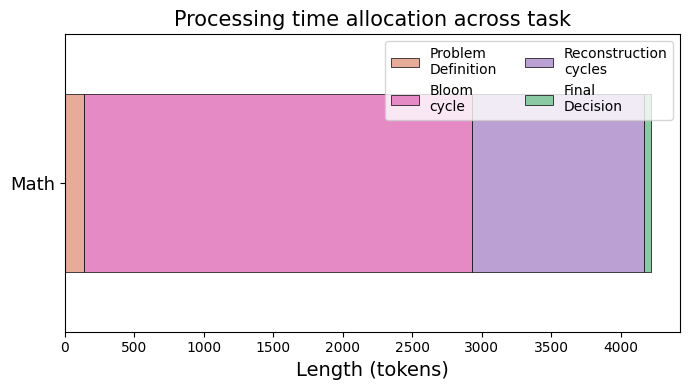

In [5]:
# === Group and Average ===
test = df.groupby('dataset')[['define_len', 'bloom_len', 'cycling_len', 'decision_len']].mean()

# Desired Order
desired_order = ['math_reasoning']
test = test.reindex(desired_order)

# === Plot ===
colors = {
    "define_len": "#E7AB9A",  # Problem Definition
    "bloom_len": "#E58AC4",   # Bloom cycle
    "cycling_len": "#BBA1D3", # Reconstruction cycles
    "decision_len": "#8AC9A3" # Final Decision
}

fig, ax = plt.subplots(figsize=(7, 4))
test.plot(kind='barh', stacked=True, ax=ax, color=colors.values(), edgecolor='black', width=0.75, linewidth=0.5)

# Labels and Title
ax.set_xlabel("Length (tokens)", size=14)
ax.set_ylabel("")
ax.set_yticks([0], ['Math'], size=13)
ax.set_title("Processing time allocation across task", size=15)
ax.legend(labels=["Problem\nDefinition", "Bloom\ncycle", "Reconstruction\ncycles", "Final\nDecision"], ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("plots/stage_lengths_tokens_qwen3.png", format="png", bbox_inches="tight")

print("Saved plot as stage_lengths_tokens_qwen3.png")

In [6]:
# === Extract Token Lengths for Bloom + each Cycle individually ===
def extract_cycle_lengths(answer):
    # Extract Bloom
    bloom_match = re.search(r"<BLOOM>(.*?)</BLOOM>", answer, re.DOTALL)
    bloom_len = len(tokenizer.encode(bloom_match.group(1).strip(), add_special_tokens=False)) if bloom_match else np.nan

    # Extract all cycles
    cycles = re.findall(r"<CYCLE>(.*?)</CYCLE>", answer, re.DOTALL)
    cycle_lens = [len(tokenizer.encode(c.strip(), add_special_tokens=False)) for c in cycles] if cycles else []

    return bloom_len, cycle_lens

In [7]:
# === Process Multiple Files ===
data = []
file_map = {
    "outputs/math500_qwen3_annotate/all_math500_qwen3.json": "math_reasoning",
    # "data/gsm8k_all.json": "math_reasoning",
    # "data/aime_all.json": "math_reasoning"
}

for filename, dataset in file_map.items():
    with open(filename, "r") as f:
        examples = json.load(f)

    for ex in examples:
        answer = ex["answer"]
        bloom_len, cycle_lens = extract_cycle_lengths(answer)
        data.append({
            "dataset": dataset,
            "bloom_len": bloom_len,
            "cycle_lens": cycle_lens
        })

df = pd.DataFrame(data)

Saved plot as cycles_math_tokens_qwen3.pdf


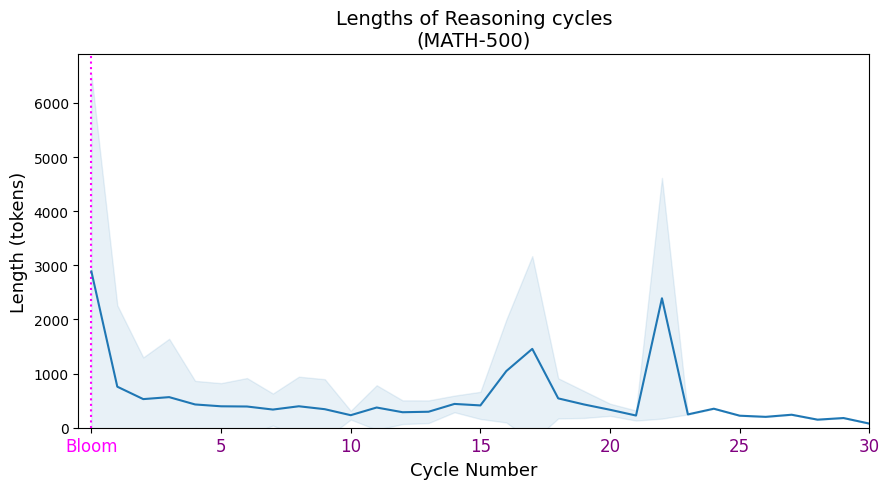

In [ ]:
# === Plot Combined Data ===
ds = 'math_reasoning'
subset = df[df['dataset'] == ds]

COLOUR = "C0"

plt.figure(figsize=(9,5))
cycle_lens = pd.DataFrame(subset.apply(
    lambda row: [row['bloom_len']] + (row['cycle_lens'] if isinstance(row['cycle_lens'], list) else []),
    axis=1
).tolist()).to_numpy(dtype=float)

mean_curve = np.nanmean(cycle_lens, axis=0)
std_curve = np.nanstd(cycle_lens, axis=0)

plt.fill_between(np.arange(cycle_lens.shape[1]), mean_curve - std_curve, mean_curve + std_curve, alpha=0.1, color=COLOUR)
plt.ylim(0)
plt.xlim(-0.5, 30)

xticks = np.arange(0, 31, 5)
xtick_labels = [str(x) for x in xticks]
xtick_labels[0] = "Bloom"
xtick_colors = ['magenta' if x == 0 else 'purple' for x in xticks]

plt.xticks(xticks, labels=xtick_labels, fontsize=12)
for tick, color in zip(plt.gca().get_xticklabels(), xtick_colors):
    tick.set_color(color)

plt.axvline(0, linestyle=":", color='magenta')

plt.ylabel("Length (tokens)", size=13)
plt.xlabel("Cycle Number", size=13)
plt.title(f"Lengths of Reasoning cycles\n(MATH-500)", size=14)
plt.plot(mean_curve, color=COLOUR)

plt.tight_layout()
plt.savefig("plots/cycles_math_tokens_qwen3.pdf", format="pdf", bbox_inches="tight")
print("Saved plot as cycles_math_tokens_qwen3.pdf")